# Final Results Summary

This notebook consolidates the finalized empirical results for the report. It loads saved pipeline outputs only: it does not construct data, select models, refit models, or redefine the analysis.

## 1. Setup and output checks

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


project_root = Path.cwd().resolve()

while project_root != project_root.parent:
    if (project_root / "modeling_specification.md").is_file():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Project root not found.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config


paths = get_paths_config()
modeling_directory = paths.tables / "modeling"
evaluation_directory = paths.tables / "evaluation"
robustness_directory = paths.tables / "robustness"
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Project root: {project_root}")
print(f"Results directory: {paths.tables}")

Project root: C:\Users\salio\OneDrive\Desktop\Master Thesis
Results directory: C:\Users\salio\OneDrive\Desktop\Master Thesis\results\tables


In [2]:
sample = pd.read_parquet(
    paths.processed / "modeling" / "modeling_sample.parquet",
    columns=["report_period", "information_date", "permno", "sample_split"],
)
baseline_test = pd.read_csv(
    modeling_directory / "selected_baseline_test_performance.csv"
)
network_test = pd.read_csv(
    modeling_directory / "selected_network_test_performance.csv"
)
gnn_test = pd.read_csv(
    modeling_directory / "selected_gnn_test_performance.csv"
)
deciles = pd.read_csv(evaluation_directory / "fragility_decile_quarterly.csv")
rank_correlations = pd.read_csv(
    evaluation_directory / "fragility_rank_correlations.csv"
)
strategy_daily = pd.read_parquet(
    evaluation_directory / "fragility_strategy_daily_returns.parquet"
)
strategy_performance = pd.read_csv(
    evaluation_directory / "fragility_strategy_performance.csv"
)
strategy_alpha = pd.read_csv(
    evaluation_directory / "fragility_strategy_alpha.csv"
)
prediction_robustness = pd.read_csv(
    robustness_directory / "prediction_robustness_performance.csv"
)
investment_robustness = pd.read_csv(
    robustness_directory / "investment_robustness_performance.csv"
)
cost_robustness = pd.read_csv(
    robustness_directory / "investment_robustness_costs.csv"
)
alpha_robustness = pd.read_csv(
    robustness_directory / "investment_robustness_alpha_hac.csv"
)

In [3]:
assert set(sample["sample_split"]) == {"train", "validation", "test"}
assert not sample.duplicated(["report_period", "permno"]).any()
assert len(baseline_test) == len(network_test) == len(gnn_test) == 1
assert len(rank_correlations) == 8
assert deciles.groupby("report_period")["fragility_decile"].nunique().eq(10).all()
assert len(strategy_daily) == 502
assert strategy_daily["date"].is_monotonic_increasing
assert len(prediction_robustness) == 4
assert set(cost_robustness["cost_bps"]) == {10, 25, 50}
assert set(alpha_robustness["hac_lag"]) == {5, 21, 63}

print(f"Modeling observations: {len(sample):,}")
print(f"Held-out test quarters: {rank_correlations['report_period'].nunique()}")
print(f"Continuous strategy days: {len(strategy_daily):,}")
print("Final-results input checks: PASS")

Modeling observations: 184,018
Held-out test quarters: 8
Continuous strategy days: 502
Final-results input checks: PASS


## 2. Modeling sample

In [4]:
split_order = ["train", "validation", "test"]
sample_summary = (
    sample.groupby("sample_split", as_index=False)
    .agg(
        observations=("permno", "size"),
        stocks=("permno", "nunique"),
        quarters=("report_period", "nunique"),
        first_quarter=("report_period", "min"),
        last_quarter=("report_period", "max"),
    )
    .set_index("sample_split")
    .loc[split_order]
    .reset_index()
)
sample_summary["first_quarter"] = pd.to_datetime(sample_summary["first_quarter"]).dt.to_period("Q").astype(str)
sample_summary["last_quarter"] = pd.to_datetime(sample_summary["last_quarter"]).dt.to_period("Q").astype(str)
display(
    sample_summary.style.format(
        {"observations": "{:,.0f}", "stocks": "{:,.0f}", "quarters": "{:.0f}"}
    )
)

,sample_split,observations,stocks,quarters,first_quarter,last_quarter
0,train,"123,791","5,701",34,2013Q2,2021Q3
1,validation,"29,716","4,733",7,2022Q1,2023Q3
2,test,"30,511","4,255",8,2024Q1,2025Q4


The chronological split keeps model selection separate from the final eight-quarter test evaluation. The unit of observation is one eligible stock-quarter.

## 3. Predictive model comparison

Each reported model was selected using validation data within its pre-specified family. This section compares those already-selected models once on the held-out test sample. Lower MAE and RMSE are better; higher $R^2$ and Spearman correlation are better.

In [5]:
test_models = pd.concat(
    [
        baseline_test.assign(model_family="Market baseline"),
        network_test.assign(model_family="Engineered network features"),
        gnn_test.assign(model_family="Graph neural network"),
    ],
    ignore_index=True,
)
display(
    test_models[
        [
            "model_family",
            "model",
            "observations",
            "mae",
            "rmse",
            "r2",
            "mean_quarterly_spearman",
        ]
    ].style.format(
        {
            "observations": "{:,.0f}",
            "mae": "{:.4f}",
            "rmse": "{:.4f}",
            "r2": "{:.3f}",
            "mean_quarterly_spearman": "{:.3f}",
        }
    )
)

,model_family,model,observations,mae,rmse,r2,mean_quarterly_spearman
0,Market baseline,xgboost_augmented,"30,511",0.0904,0.1249,0.504,0.739
1,Engineered network features,xgboost_network,"30,511",0.0900,0.1245,0.507,0.738
2,Graph neural network,temporal_graphsage,"30,511",0.0898,0.1263,0.493,0.739


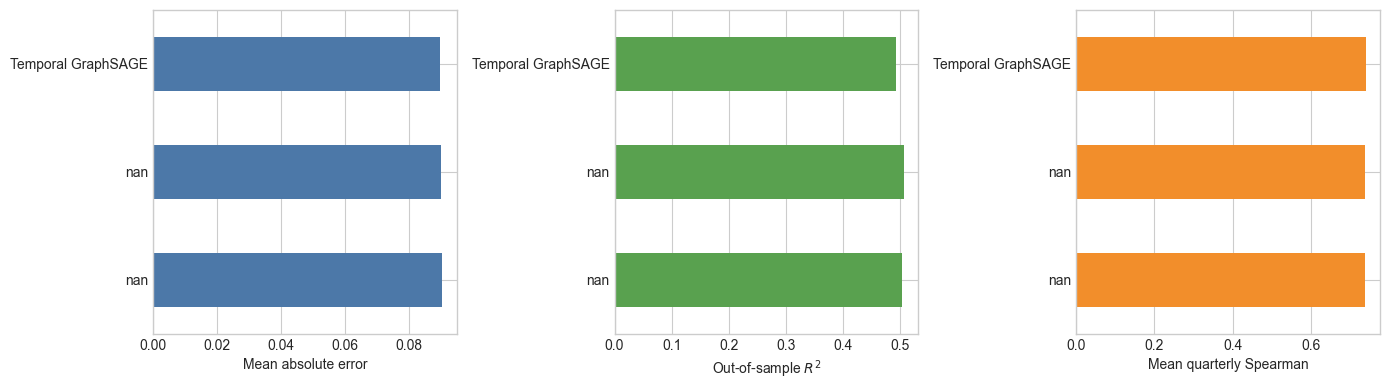

In [6]:
model_labels = {
    "xgboost_market": "Market XGBoost",
    "ridge_network": "Network ridge",
    "temporal_graphsage": "Temporal GraphSAGE",
}
plot_models = test_models.assign(label=test_models["model"].map(model_labels)).set_index("label")
metrics = [
    ("mae", "Mean absolute error", "#4c78a8"),
    ("r2", "Out-of-sample $R^2$", "#59a14f"),
    ("mean_quarterly_spearman", "Mean quarterly Spearman", "#f28e2b"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for axis, (metric, title, color) in zip(axes, metrics):
    plot_models[metric].plot.barh(ax=axis, color=color)
    axis.set(xlabel=title, ylabel="")

fig.tight_layout()
fig.savefig(paths.figures / "07_01_test_model_comparison.pdf")
plt.show()

The tuned market-only XGBoost model remains the primary model because it has the lowest validation MAE. On the fixed test sample, temporal GraphSAGE has slightly lower MAE (0.0910 versus 0.0914), but the market model has lower RMSE, higher $R^2$ (0.496 versus 0.486), and higher mean quarterly Spearman correlation (0.738 versus 0.727). The engineered network model is weaker. The evidence therefore does not show consistent incremental predictive value from the tested ownership-network representations.

## 4. Fragility Score and realized downside risk

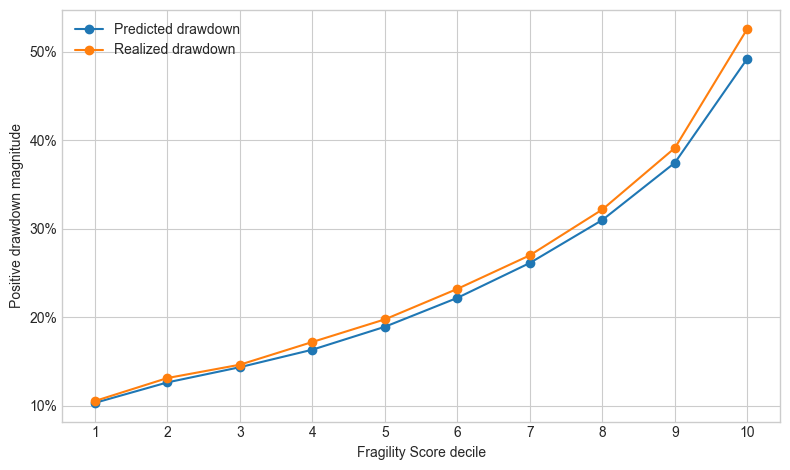

In [7]:
average_deciles = (
    deciles.groupby("fragility_decile", as_index=False)
    .agg(
        mean_predicted_drawdown=("mean_predicted_drawdown", "mean"),
        mean_realized_drawdown=("mean_realized_drawdown", "mean"),
    )
)
fig, axis = plt.subplots(figsize=(8, 4.8))
axis.plot(
    average_deciles["fragility_decile"],
    average_deciles["mean_predicted_drawdown"],
    marker="o",
    label="Predicted drawdown",
)
axis.plot(
    average_deciles["fragility_decile"],
    average_deciles["mean_realized_drawdown"],
    marker="o",
    label="Realized drawdown",
)
axis.set(
    xlabel="Fragility Score decile",
    ylabel="Positive drawdown magnitude",
)
axis.set_xticks(range(1, 11))
axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
axis.legend()
fig.tight_layout()
fig.savefig(paths.figures / "07_01_fragility_decile_drawdown.pdf")
plt.show()

In [8]:
score_summary = pd.DataFrame(
    {
        "Statistic": [
            "Mean stock-level quarterly Spearman",
            "Mean decile-level Spearman",
            "Mean D10 minus D1 realized drawdown",
        ],
        "Value": [
            rank_correlations["stock_spearman"].mean(),
            rank_correlations["decile_spearman"].mean(),
            rank_correlations["top_minus_bottom_mean_drawdown"].mean(),
        ],
    }
)
display(score_summary.style.format({"Value": "{:.3f}"}))

,Statistic,Value
0,Mean stock-level quarterly Spearman,0.739
1,Mean decile-level Spearman,1.000
2,Mean D10 minus D1 realized drawdown,0.421


The score provides strong cross-sectional ordering. Its mean stock-level quarterly Spearman correlation with realized drawdown is 0.738, every quarter has monotonic decile averages, and the average realized drawdown difference between deciles 10 and 1 is 41.79 percentage points. This is the central economic interpretation of the model: the standardized score ranks stocks by prospective downside fragility.

## 5. Supplementary investment evaluation

The internal benchmark holds all eligible stocks under the same equal-weighted, quarterly rebalancing rule. The screened portfolio excludes Fragility Score decile 10. CRSP total-market performance is an external reference with a different universe and weighting scheme.

In [9]:
strategy_labels = {
    "all_stocks": "All eligible stocks",
    "exclude_most_fragile_decile": "Exclude fragility decile 10",
    "crsp_total_market": "CRSP total market",
}
performance_display = strategy_performance.copy()
performance_display["Strategy"] = performance_display["strategy"].map(strategy_labels)
display(
    performance_display[
        [
            "Strategy",
            "annualized_return",
            "annualized_volatility",
            "sharpe_ratio",
            "maximum_drawdown",
            "downside_volatility",
        ]
    ].style.format(
        {
            "annualized_return": "{:.2%}",
            "annualized_volatility": "{:.2%}",
            "sharpe_ratio": "{:.3f}",
            "maximum_drawdown": "{:.2%}",
            "downside_volatility": "{:.2%}",
        }
    )
)

,Strategy,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,All eligible stocks,7.82%,20.37%,0.239,26.50%,14.14%
1,Exclude fragility decile 10,14.13%,19.52%,0.532,24.11%,13.30%
2,CRSP total market,18.98%,16.37%,0.854,19.11%,11.14%


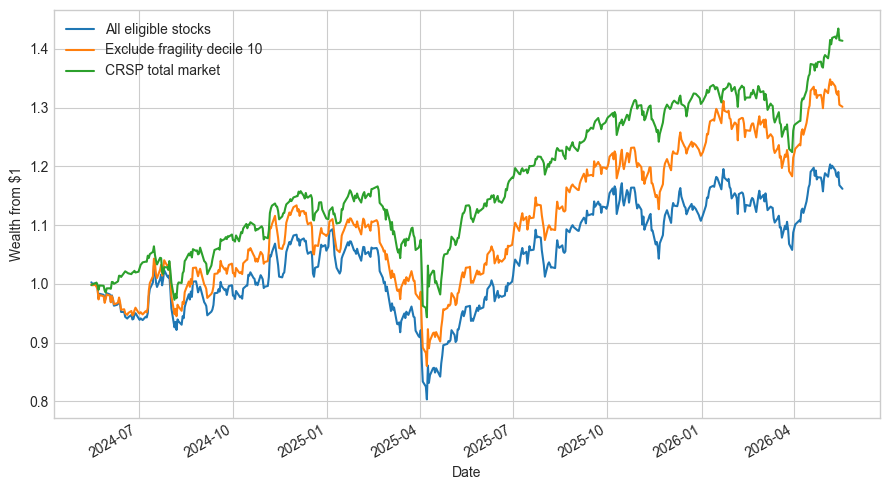

In [10]:
wealth = pd.DataFrame(
    {
        "All eligible stocks": (1 + strategy_daily["all_stocks_return"]).cumprod().to_numpy(),
        "Exclude fragility decile 10": (1 + strategy_daily["screened_return"]).cumprod().to_numpy(),
        "CRSP total market": (1 + strategy_daily["crsp_market_return"]).cumprod().to_numpy(),
    },
    index=strategy_daily["date"],
)
axis = wealth.plot(figsize=(9, 5))
axis.set(xlabel="Date", ylabel="Wealth from $1")
plt.tight_layout()
axis.figure.savefig(paths.figures / "07_01_cumulative_performance.pdf")
plt.show()

In [11]:
ff_alpha = strategy_alpha.loc[strategy_alpha["model"] == "ff5_momentum"].copy()
alpha_labels = {
    "all_stocks": "All eligible stocks",
    "exclude_most_fragile_decile": "Exclude fragility decile 10",
    "screened_minus_all_stocks": "Screened minus all stocks",
}
ff_alpha["Portfolio"] = ff_alpha["portfolio"].map(alpha_labels)
display(
    ff_alpha[
        ["Portfolio", "annualized_alpha", "alpha_t_statistic", "alpha_p_value"]
    ].style.format(
        {
            "annualized_alpha": "{:.2%}",
            "alpha_t_statistic": "{:.3f}",
            "alpha_p_value": "{:.4f}",
        }
    )
)

,Portfolio,annualized_alpha,alpha_t_statistic,alpha_p_value
1,All eligible stocks,-5.20%,-1.345,0.1786
3,Exclude fragility decile 10,0.27%,0.110,0.9123
5,Screened minus all stocks,5.47%,2.795,0.0052


Screening improves the controlled equal-weight benchmark: annualized return rises from 7.82% to 14.00%, while maximum drawdown falls from 26.50% to 24.11%. The screened-minus-all portfolio has an annualized FF5-plus-momentum alpha of 5.32% ($p=0.0046$), but the screened portfolio's standalone alpha is approximately zero. Moreover, the CRSP total-market index outperforms both internal portfolios. The evidence supports the score as a downside-risk screen, not a claim of standalone deployable alpha.

## 6. Robustness

In [12]:
target_labels = {
    "future_downside_volatility_63d": "Downside volatility (63d)",
    "future_worst_five_day_loss_63d": "Worst five-day loss (63d)",
    "future_max_drawdown_21d": "Maximum drawdown (21d)",
    "future_max_drawdown_126d": "Maximum drawdown (126d)",
}
prediction_display = prediction_robustness.copy()
prediction_display["Outcome"] = prediction_display["target"].map(target_labels)
display(
    prediction_display[
        [
            "Outcome",
            "test_observations",
            "test_quarters",
            "r2",
            "mean_quarterly_spearman",
            "mean_decile_spearman",
        ]
    ].style.format(
        {
            "test_observations": "{:,.0f}",
            "test_quarters": "{:.0f}",
            "r2": "{:.3f}",
            "mean_quarterly_spearman": "{:.3f}",
            "mean_decile_spearman": "{:.3f}",
        }
    )
)

,Outcome,test_observations,test_quarters,r2,mean_quarterly_spearman,mean_decile_spearman
0,Downside volatility (63d),"30,511",8,0.483,0.841,1.000
1,Worst five-day loss (63d),"30,472",8,0.437,0.748,1.000
2,Maximum drawdown (21d),"30,509",8,0.395,0.690,1.000
3,Maximum drawdown (126d),"26,819",7,0.540,0.752,1.000


In [13]:
robustness_labels = {
    "equal_all": "EW: all stocks",
    "equal_exclude_d10": "EW: exclude D10",
    "equal_exclude_top20": "EW: exclude top 20%",
    "value_all": "VW: all stocks",
    "value_exclude_d10": "VW: exclude D10",
}
investment_display = investment_robustness.copy()
investment_display["Strategy"] = investment_display["strategy"].map(robustness_labels)
display(
    investment_display[
        ["Strategy", "annualized_return", "sharpe_ratio", "maximum_drawdown"]
    ].style.format(
        {
            "annualized_return": "{:.2%}",
            "sharpe_ratio": "{:.3f}",
            "maximum_drawdown": "{:.2%}",
        }
    )
)

,Strategy,annualized_return,sharpe_ratio,maximum_drawdown
0,EW: all stocks,7.82%,0.239,26.50%
1,EW: exclude D10,14.13%,0.532,24.11%
2,EW: exclude top 20%,13.96%,0.542,23.49%
3,VW: all stocks,19.32%,0.861,19.39%
4,VW: exclude D10,19.24%,0.858,19.37%


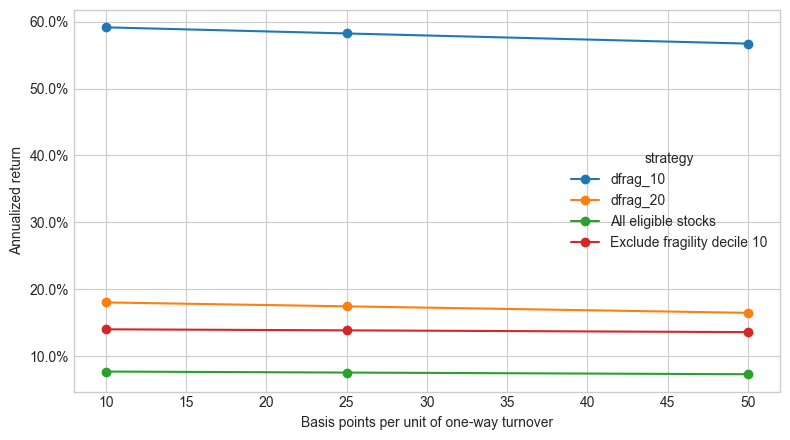

,hac_lag,annualized_alpha,alpha_t_statistic,alpha_p_value
0,5,5.47%,2.795,0.0052
1,21,5.47%,2.578,0.0099
2,63,5.47%,2.677,0.0074


In [14]:
cost_plot = cost_robustness.pivot(
    index="cost_bps",
    columns="strategy",
    values="annualized_return",
).rename(
    columns={
        "equal_all": "All eligible stocks",
        "equal_exclude_d10": "Exclude fragility decile 10",
    }
)
axis = cost_plot.plot(marker="o", figsize=(8, 4.5))
axis.set(
    xlabel="Basis points per unit of one-way turnover",
    ylabel="Annualized return",
)
axis.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.1%}"))
plt.tight_layout()
axis.figure.savefig(paths.figures / "07_01_cost_sensitivity.pdf")
plt.show()

display(
    alpha_robustness[
        ["hac_lag", "annualized_alpha", "alpha_t_statistic", "alpha_p_value"]
    ].style.format(
        {
            "annualized_alpha": "{:.2%}",
            "alpha_t_statistic": "{:.3f}",
            "alpha_p_value": "{:.4f}",
        }
    )
)

Prediction quality remains positive for all alternative outcomes and horizons, with test $R^2$ between 0.400 and 0.547 and mean quarterly Spearman correlations between 0.692 and 0.844. The equal-weight investment result survives excluding the highest 20%, transaction costs up to 50 basis points, and alternative HAC lags. It does not survive economically under value weighting: excluding decile 10 produces almost no change relative to the value-weighted universe. The portfolio result is therefore concentrated outside the largest stocks and should remain supplementary.

## 7. Report placement

### Main report

1. Modeling-sample summary.
2. Held-out comparison of the three selected model families.
3. Fragility Score decile figure and compact ranking summary.
4. Primary equal-weight portfolio comparison, with the CRSP market as context.
5. Compact prediction and investment robustness tables.

### Appendix

1. Complete validation-model searches and hyperparameter details.
2. Quarter-by-quarter rank correlations and decile tables.
3. Complete CAPM and FF5-plus-momentum regressions.
4. Turnover by formation date, every transaction-cost scenario, and HAC-lag details.
5. Detailed network and GNN diagnostics.

## 8. Overall conclusion

The tuned market model predicts future maximum drawdown and produces a strongly ordered Fragility Score. Engineered network features do not improve it, while temporal GraphSAGE provides mixed evidence: slightly lower fixed-test MAE but weaker validation MAE and weaker supporting test metrics. The market model therefore remains primary under the frozen validation rule. Stocks ranked as more fragile subsequently experience materially worse downside outcomes. Excluding the highest-risk decile improves a matched equal-weight portfolio's downside profile, but the benefit is weighting-sensitive, the standalone screened portfolio has no significant factor-adjusted alpha, and the external market benchmark remains stronger. These findings support the Fragility Score as a predictive downside-risk measure rather than as evidence of a deployable trading strategy.